# Лабораторная работа №6

## Задание 1

В этом задании требуется выполнить сингулярное разложение матрицы изображения. Это позволяет выделить ключевую информацию, определяющую изображение, и удалить менее значимые данные. Такой подход позволяет существенно уменьшить размер файла изображения при минимальной потере качества.

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

#### Алгоритм функции сжатия изображения:

В функцию передается путь к изображению и массив возможных вариантов параметра $k$ в процентах от общего количества сингулярных чисел матрицы изображения.

1. Загрузка изображения по переданному пути и перевод его в массив. Стоит отметить, что в данном случае берется лишь 1 из трех каналов RGB, т.к. предполагается, что изображение изначально черно-белое (в таком случае значения всех каналов равны).
2. Вычисление сингулярного разложения матрицы изображения.
3. Для каждого варианта параметра $k$ проводится сжатие изображения, путем сохранения лишь $k$ сингулярных чисел, а также вычисляется коэффициент сжатия размера файла.
4. Далее полученные изображения выводятся в виде таблицы.

In [22]:
def compress_image(image_path, k_percent_values):
    # Загрузка изображения
    image = Image.open(image_path)
    image_array = np.array(image)[:, :, 0]

    # Основная магия: SVD-разложение
    U, S, Vt = np.linalg.svd(image_array, full_matrices=False)

    compression_ratios = []
    compressed_images = []
    for k_percent in k_percent_values:
        k = int(k_percent * min(image_array.shape) / 100)
        S_reduced = S[:k]
        U_reduced = U[:, :k]
        Vt_reduced = Vt[:k, :]

        image_array_reduced = (U_reduced * S_reduced) @ Vt_reduced
        image_array_reduced = np.clip(image_array_reduced, 0, 255).astype(np.uint8)

        # Расчет коэффициента сжатия
        original_size = image_array.shape[0] * image_array.shape[1]
        compressed_size = k * (1 + image_array.shape[0] + image_array.shape[1])
        compression_ratio = 100 * (1 - compressed_size / original_size)
        compression_ratios.append(compression_ratio)

        compressed_images.append((k, image_array_reduced, compression_ratio))

    # Отображение изображений
    num_images = len(compressed_images)
    cols = 2
    rows = (num_images + cols - 1) // cols

    img_aspect_ratio = image_array.shape[0] / image_array.shape[1]
    plt.figure(figsize=(12, rows * 7.3 * img_aspect_ratio))
    for i, (k, img, ratio) in enumerate(compressed_images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"k = {k} ({k_percent_values[i]}% синг. чисел)     Сжатие: {ratio:.2f}%")
        plt.axis("off")
    plt.suptitle(f"Сжатые изображения для {image_path}", fontsize=16)
    plt.tight_layout()
    plt.show()


Зафиксируем варианты параметра $k$ в процентах от общего количество сингулярных чисел.

In [25]:
k_percent_values = [30, 20, 10, 5, 4, 3, 2, 1, 0.5, 0.1]

#### Продемонстрируем работу алгоритма на трех примерах

Первое изображение имеет стандартное разрешение

In [37]:
Image.open("ryan.jpg").size

(1920, 1086)

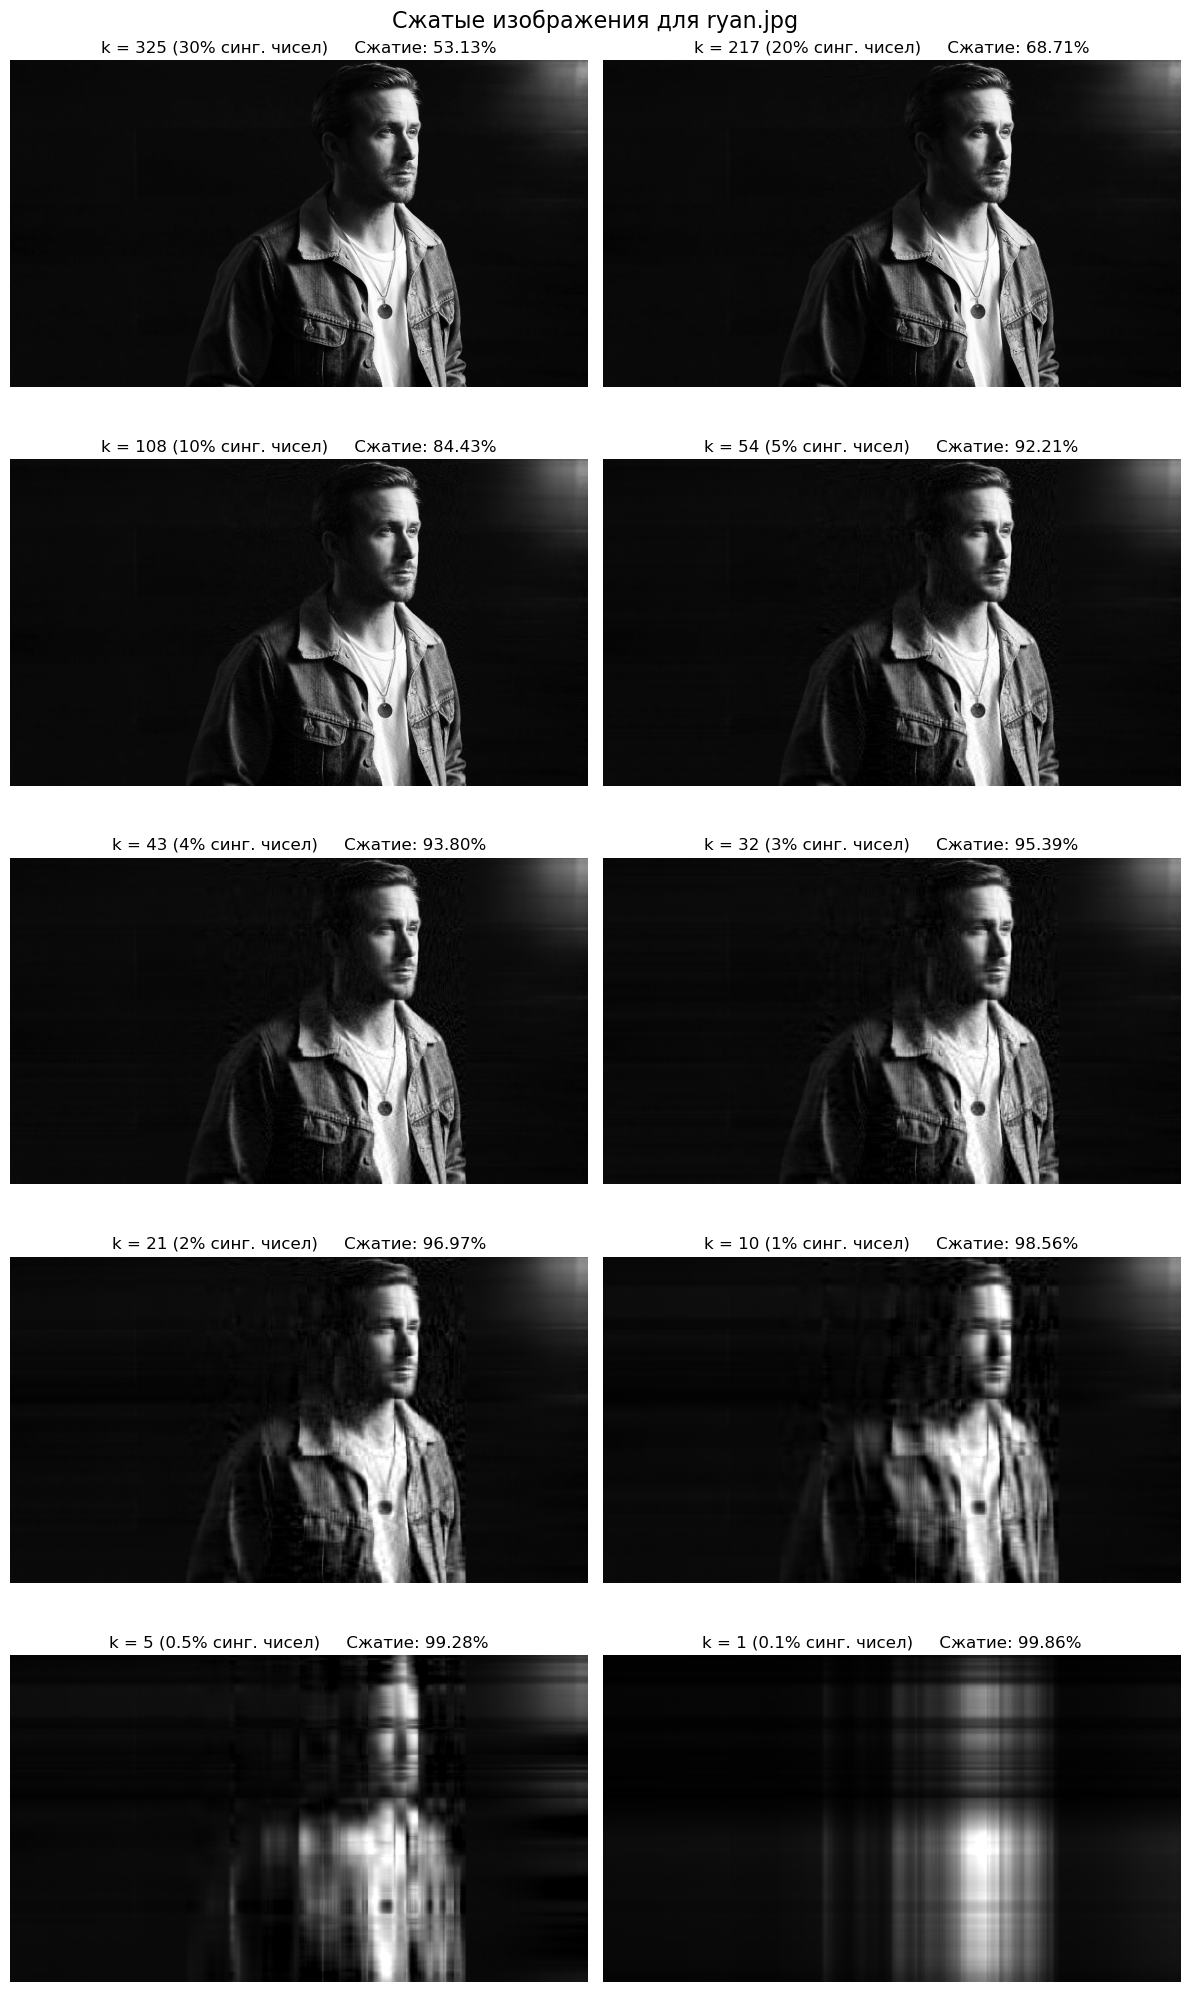

In [32]:
compress_image("ryan.jpg", k_percent_values)

Следующее изображение имеет широкий формат

In [38]:
Image.open("oppenheimer.jpg").size

(2812, 1009)

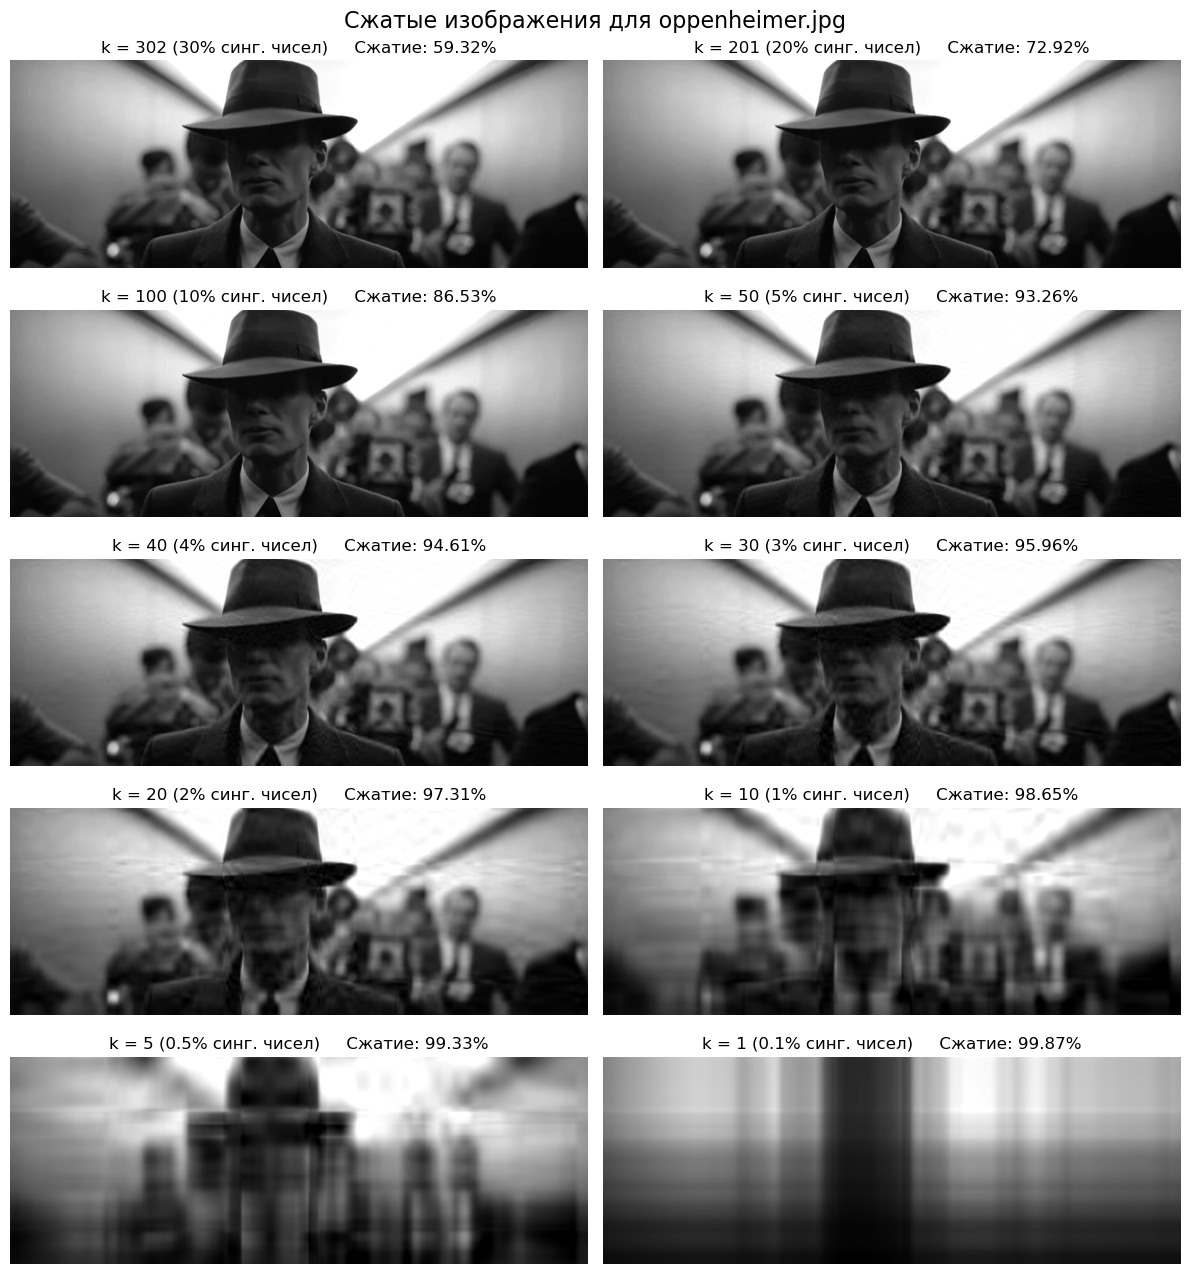

In [31]:
compress_image("oppenheimer.jpg", k_percent_values)

Последнее изображение имеет более высокое разрешение

In [36]:
Image.open("border_collie.jpg").size

(3973, 2248)

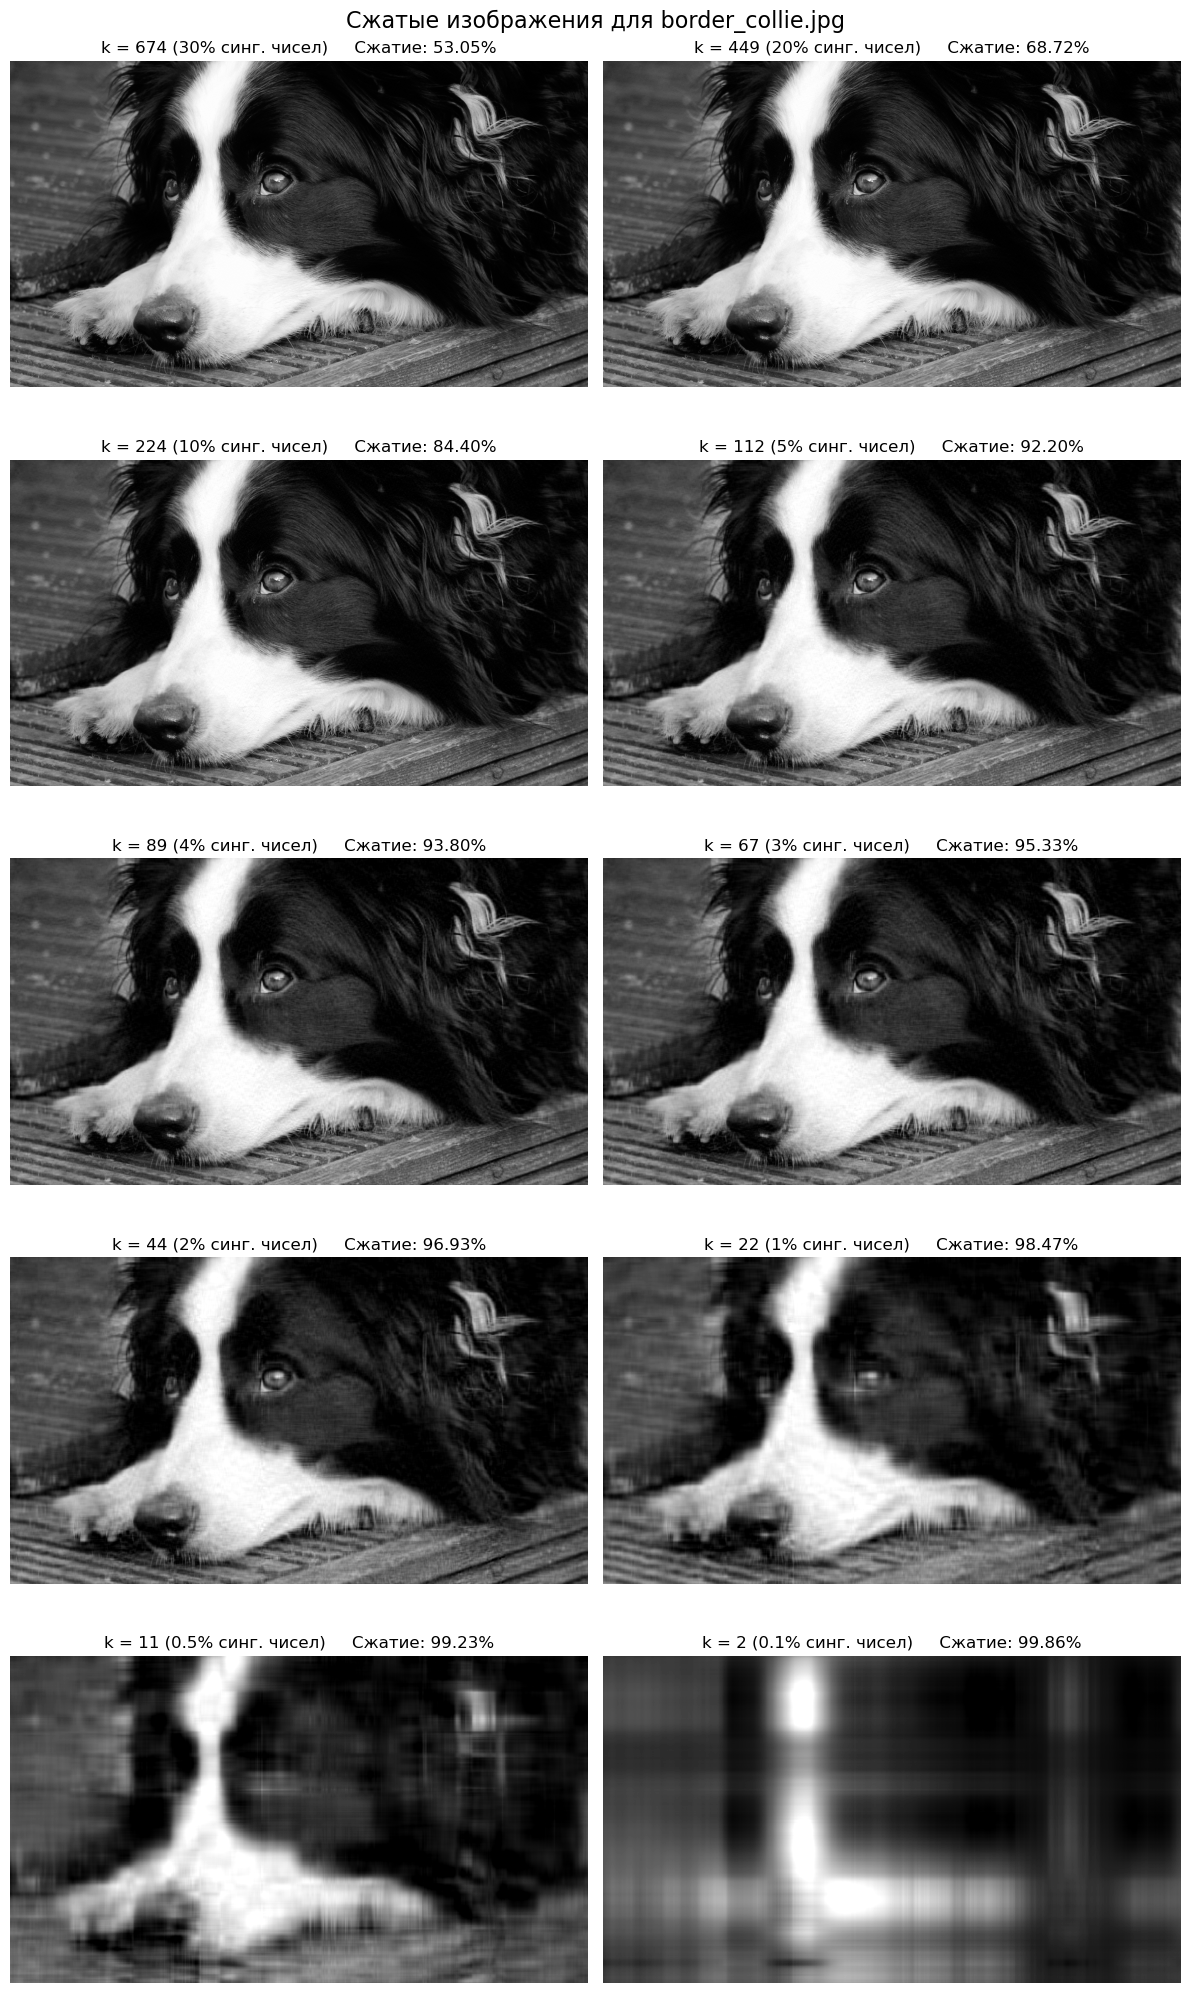

In [33]:
compress_image("border_collie.jpg", k_percent_values)

### Вывод

Сжатие, основанное на сингулярном разложении, позволяет существенно уменьшить размер файла. В приведенных примерах видимое качество изображения сохранялось даже при сохранении только 5-10% сингулярных чисел. При этом коэффициент сжатия достигал около 90%, что подтверждает высокую эффективность метода.

Также стоит отметить интересное наблюдение: даже при крайне низком количестве оставленных сингулярных чисел — 1% или даже 0,5% — изображения остаются узнаваемыми и, что важно, сохраняют часть деталей.

## Задание 2

В этом задании нужно провести **латентно-семантический анализ** текста (**LSA**). Этот метод помогает выявить скрытые *темы* в тексте, а также определить степень связи каждого предложения (*документа*) и каждого слова (*терма*) с выявленными темами.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymorphy3
import nltk
from wordcloud import WordCloud
import json
import re

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sokol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Загрузим текст из файла. Легко заметить, что текст состоит из предложений на две темы: лингвистика и миграция птиц.

Посмотрим, справится ли LSA с выявлением данных тем.

In [64]:
with open('./data4.txt', 'r', encoding='utf-8') as file:
    raw_documents = json.load(file)
raw_documents

['Семантика анализирует значения слов и фраз.',
 'Лингвистика изучает структуру и развитие языков.',
 'Совы обычно не мигрируют, но некоторые виды могут менять места обитания.',
 'Перелётные птицы совершают миграции между регионами в поисках пищи.',
 'Ласточки возвращаются весной, знаменуя окончание зимы.',
 'Анализ текстов помогает выявить стилистические особенности автора.',
 'Гуси мигрируют большими стаями, преодолевая тысячи километров.',
 'Литературные тексты часто содержат сложные метафоры и аллегории.',
 'Скворцы собираются в большие группы перед началом миграции.',
 'Перелётные птицы ориентируются по солнцу и магнитному полю Земли.',
 'Синтаксис помогает понять, как слова соединяются в предложения.',
 'Аисты гнездятся в одном регионе, но зимуют в тёплых странах.',
 'Фонетика изучает звуки речи и их артикуляцию.',
 'Морфология исследует формы слов и их изменения.',
 'Письменные тексты хранят культурное наследие и знания поколений.',
 'Журавли известны своими длинными перелётами 

Подготовим текст к анализу: приведем к нижнему регистру, удалим знаки препинания и разобьем на отдельные слова. Затем применим **лемматизацию** для каждого слова.

Из полученных слов составим **список документов** и **словарь** всех термов.

In [65]:
morph = pymorphy3.MorphAnalyzer()
dictionary = set()
documents = []

for document in raw_documents:
    document = document.lower()
    document = re.sub(r'[^\w\s]', '', document)
    words = document.split()
    lemmas = []
    for word in words:
        if word not in nltk.corpus.stopwords.words('russian'):
            lemma = morph.parse(word)[0].normal_form
            lemmas.append(lemma)
            dictionary.add(lemma)
    documents.append(lemmas)

dictionary = sorted(list(dictionary))
dictionary

['автор',
 'аист',
 'аллегория',
 'анализ',
 'анализировать',
 'артикуляция',
 'база',
 'больший',
 'весна',
 'вид',
 'возвращаться',
 'выявить',
 'гнездиться',
 'группа',
 'гусь',
 'длинный',
 'доступность',
 'журавль',
 'зависеть',
 'звук',
 'земля',
 'зима',
 'зимовать',
 'знаменовать',
 'знание',
 'значение',
 'известный',
 'изменение',
 'изучать',
 'использовать',
 'исследовать',
 'километр',
 'контекст',
 'корм',
 'корпусный',
 'культурный',
 'ласточка',
 'лебедь',
 'лингвистика',
 'литературный',
 'магнитный',
 'менять',
 'место',
 'метафора',
 'миграция',
 'мигрировать',
 'морфология',
 'мочь',
 'наследие',
 'наступление',
 'начало',
 'некоторый',
 'обитание',
 'обычно',
 'один',
 'окончание',
 'ориентироваться',
 'особенность',
 'отправляться',
 'перевод',
 'перелёт',
 'перелётный',
 'письменный',
 'пища',
 'поиск',
 'поколение',
 'поле',
 'помогать',
 'понимание',
 'понять',
 'предложение',
 'преодолевать',
 'птица',
 'развитие',
 'регион',
 'речь',
 'свой',
 'сезон',
 'семан

Составим **терм-документную матрицу** - матрицу соответствия термов и документов. Её столбцы отвечают за термы, строки за документы, а на их пересечении указано количество вхождений терма в документ.

Такой метод построения терм-документной матрицы аналогичен классу **CountVectorizer** из библиотеки *scikit-learn*. Существует также более сложный и часто более эффективный метод **TFIDF**, основанный на отношении частоты появления терма в документе к частоте появляения терма во всем тексте (класс **TfidfVectorizer** в *scikit-learn*). Но на нашем наборе текстов данный метод показал результат хуже, чем *CountVectorizer*. Возможно это связано с небольшим размером датасетов и на бо́льших объемах он покажет себя лучше.

In [66]:
document_term_matrix = []

for document in documents:
    document_vector = []
    for term in dictionary:
        document_vector.append(document.count(term))
    document_term_matrix.append(document_vector)

np.array(document_term_matrix)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

Найдем сингулярное разложение полученной терм-документной матрицы.

In [67]:
U, S, Vt = np.linalg.svd(document_term_matrix, full_matrices=False)

S[:2]

array([3.39639935, 3.28746425])

Сингулярные числа терм-документной матрицы соответствуют скрытым **темам** нашего набора документов. Величина этих значений показывает "важность" каждой из тем для всего текста.

Каждый столбец матрицы $U$ (левый сингулярный вектор терм-документной матрицы) соответствует одной теме и показывает насколько сильно каждый из **документов** связан с представленной темой.

Величина $i$-той компоненты данного вектора показывает величину связи $i$-того документа с темой. Необходимо отметить, что важна именно **абсолютная** величина компоненты, т.к. знак здесь не имеет значения. Отсутствие связи показывает нулевое значение компоненты.

Каждая строка матрицы $V$ (правый сингулярный вектор) аналогично соответствует одной теме и показывает насколько сильно каждый из **термов** связан с представленнной темой.

Таким образом, можно выделить две самые "важные" темы текста и посмотреть к каким термам и документам они больше всего относятся.

Найдем топ-5 слов (термов) сильнее всех связанных с двумя самыми важными темами и выведем их.

Также построим для каждой темы "облако слов" из всего словаря. Величина слова в нем отображает его связь с данной темой.

Тема 1: текст, анализ, язык, лингвистика, помогать



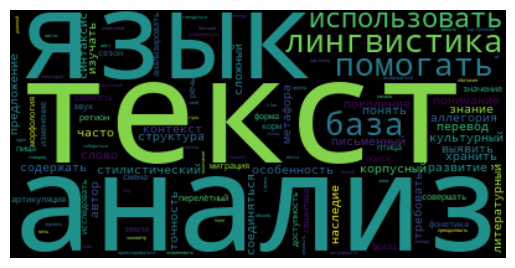




Тема 2: птица, миграция, перелётный, регион, совершать



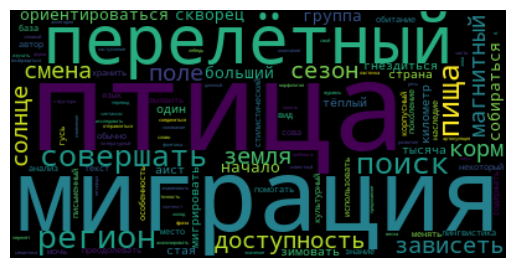

In [68]:
for i, topic in enumerate(Vt[:2]):
    top_words_idx = np.abs(topic).argsort()[::-1]
    top_words = [dictionary[idx] for idx in top_words_idx]
    print(f"Тема {i + 1}: {', '.join(top_words[:5])}\n")

    wordcloud = WordCloud().generate(' '.join(top_words))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()
    print("\n\n")

Можно заметить, что LSA правильно выявил две основные темы текста.

Теперь аналогичным образом найдем топ-5 документов для каждой из тем.

In [69]:
U_abs = np.round(np.abs(U), 5)
document_topic_table = pd.DataFrame({'Document': raw_documents, 'Topic 1': U_abs[:, 0], 'Topic 2': U_abs[:, 1]})

In [70]:
document_topic_table.sort_values(by='Topic 1', ascending=False)[:5]

,Document,Topic 1,Topic 2
16,Корпусная лингвистика использует базы текстов ...,0.54187,0.0
5,Анализ текстов помогает выявить стилистические...,0.50483,0.0
14,Письменные тексты хранят культурное наследие и...,0.38932,0.0
7,Литературные тексты часто содержат сложные мет...,0.38932,0.0
18,Перевод текста требует точности и понимания ко...,0.32975,0.0


In [71]:
document_topic_table.sort_values(by='Topic 2', ascending=False)[:5]

,Document,Topic 1,Topic 2
3,Перелётные птицы совершают миграции между реги...,0.0,0.63383
19,Миграции птиц зависят от смены сезонов и досту...,0.0,0.52413
9,Перелётные птицы ориентируются по солнцу и маг...,0.0,0.47060
8,Скворцы собираются в большие группы перед нача...,0.0,0.25732
11,"Аисты гнездятся в одном регионе, но зимуют в т...",0.0,0.16647


### Вывод

Метод латентного-семантического анализа успешно справился с выявлением двух основных тем текста. Кроме того, он определил конкретные слова и предложения, которые лучше всего отражают каждую тему.